# First RF Spin Echo at 0.2516 T

**DELTA DIY MRI Workshop — Acquisition and Console Team**  
**Milestone:** RF spin echo → 1D projection → 2D spin echo  
**This notebook section:** RF-only spin echo + RF Pulsewidth calibration

In this notebook, we start with the simplest Day 1 acquisition milestone: generate a **90°–180° RF spin echo** and observe the echo signal before adding spatial encoding gradients.

This RF-only spin echo section is designed to be reused in the next calibration notebook for **RF pulse-width calibration**.


## Workshop rhythm

We will continue using the same structure as the workshop:

| Block | Purpose in this RF SE section |
|---|---|
| *Learn* | Understand what the 90° and 180° RF pulses do |
| *Design* | Set scanner-specific parameters for the 0.2516 T system |
| *Build* | Construct and inspect the PyPulseq RF spin echo sequence |
| *Scan* | Export the `.seq` file and use it as the first scanner milestone |

**Day 1 milestone:** observe the first RF spin echo and then extend toward a 1D projection.


---
# 1. Learn: What are we trying to create?

A spin echo uses two RF pulses:

1. A **90° excitation pulse** tips longitudinal magnetization into the transverse plane.
2. After a delay of **TE/2**, a **180° refocusing pulse** reverses dephasing.
3. After another **TE/2**, spins rephase and form a measurable echo.

For this first sub-milestone, we will intentionally keep gradients off.

That means this is **not yet a spatially encoded image**. It is a system-level RF and receive-chain experiment.

We are asking:

- Can we transmit RF at the correct Larmor frequency?
- Can we generate a 90° pulse and 180° pulse?
- Can we observe a spin echo at the expected TE?
- Can we reuse this sequence for RF pulse-width calibration?


---
# 2. Design: Scanner and sequence parameters

We tailor the sequence to the DELTA DIY MRI system (shortname - DELTA2).

| Parameter | Initial value | Notes |
|---|---:|---|
| Main field strength | 0.2516 T | Low-field scanner |
| Proton gyromagnetic ratio | 42.576 MHz/T | Approximate |
| Larmor frequency | ~10.713 MHz | Calculated below |
| Object | Ex vivo sheep brain | Initial target |
| Sequence | RF spin echo | 90°–180° |
| Spatial encoding | Off | No readout or phase gradient yet |
| Initial TE | 10 ms | Editable |
| Initial TR | 1000 ms | Editable |
| Initial 90° pulse width | 150 µs | Placeholder; calibrate on scanner - separate notebook |
| Initial 180° pulse width | 300 µs | Starting assumption: 2 × 90° pulse width |

> Before scanning, replace placeholder RF and hardware values with the measured/approved scanner settings.


## Setup

In [1]:
import sys

!{sys.executable} -m pip install --no-cache-dir --force-reinstall \
  "numpy==1.23.5" \
  "pypulseq==1.4.0" \
  "matplotlib"

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.4/13.4 MB 13.5 MB/s  0:00:00 eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.2/8.2 MB 15.3 MB/s  0:00:00 eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 20.6 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.8/4.8 MB 14.0 MB/s  0:00:00eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 22.4/22.4 MB 16.2 MB/s  0:00:01 eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.7/2.7 MB 20.6 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.5/40.5 MB 15.4 MB/s  0:00:02 eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.3/4.3 MB 13.9 MB/s  0:00:00 eta 0:00:01
  Attempting uninstall: tqdm
    Found existing installation: tqdm 4.70.0
    Uninstalling tqdm-4.70.0:
      Successfully uninstalled tqdm-4.70.0
  Attempting uninstall: six━━━━━━━━━━━━━━━━━━━━━  0/19 [tqdm]
    Found existing installation: six 1.17.0━  0/19 [tqdm]
    Uninstalling six-1.17.0:━━━━━━━━━━━━━━━━  0/19 [tqdm]
      

## Section I — RF Pulse-Spin Echo

# Verify and import packages

In [2]:
import sys
import numpy as np
import pypulseq as pp
import matplotlib.pyplot as plt

print("Python executable:", sys.executable)
print("NumPy version:", np.__version__)
print("NumPy location:", np.__file__)
print("PyPulseq location:", pp.__file__)

/opt/homebrew/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Python executable: /opt/homebrew/opt/python@3.10/bin/python3.10
NumPy version: 1.23.5
NumPy location: /opt/homebrew/lib/python3.10/site-packages/numpy/__init__.py
PyPulseq location: /opt/homebrew/lib/python3.10/site-packages/pypulseq/__init__.py


In [3]:
# ----------------------------
# DELTA DIY MRI system settings
# ----------------------------

B0_T = 0.2516
GAMMA_HZ_PER_T = 42.576e6
f0_hz = GAMMA_HZ_PER_T * B0_T

print("DELTA DIY MRI low-field scanner")
print(f"B0 field strength     : {B0_T:.4f} T")
print(f"Proton Larmor freq.   : {f0_hz/1e6:.3f} MHz")
print("Target object         : ex vivo sheep brain")


DELTA DIY MRI low-field scanner
B0 field strength     : 0.2516 T
Proton Larmor freq.   : 10.712 MHz
Target object         : ex vivo sheep brain


Expected result: the calculated Larmor frequency should be near **10.713 MHz**.

This number should be checked against the measured scanner `f0` before live acquisition.


---
# 3. Design: RF spin echo protocol

The RF spin echo protocol is deliberately simple.

The key editable values are:

- `TE`
- `TR`
- `rf90_duration`
- `rf180_duration`
- `rf_amplitude_scale`
- `adc_duration`
- `num_samples`

These are intentionally placed in one cell because the same variables will be reused in the RF pulse-width calibration notebook.


In [5]:
# ----------------------------
# RF spin echo protocol
# ----------------------------

TE = 10e-3          # echo time in seconds
TR = 1000e-3        # repetition time in seconds

# Starting values only. These should be calibrated on the scanner.
rf90_duration = 150e-6
rf180_duration = 2 * rf90_duration
rf_amplitude_scale = 1.0

# Receiver window centered around the expected echo
num_samples = 1024 # this could change based on Redpitaya settings
adc_duration = 8e-3

print("RF spin echo protocol")
print(f"TE                  : {TE*1e3:.1f} ms")
print(f"TR                  : {TR*1e3:.1f} ms")
print(f"90° pulse duration  : {rf90_duration*1e6:.1f} µs")
print(f"180° pulse duration : {rf180_duration*1e6:.1f} µs")
print(f"ADC samples         : {num_samples}")
print(f"ADC duration        : {adc_duration*1e3:.1f} ms")
print(f"RF amplitude scale  : {rf_amplitude_scale:.2f}")


RF spin echo protocol
TE                  : 10.0 ms
TR                  : 1000.0 ms
90° pulse duration  : 150.0 µs
180° pulse duration : 300.0 µs
ADC samples         : 1024
ADC duration        : 8.0 ms
RF amplitude scale  : 1.00


## Design checkpoint

Before building the PyPulseq sequence, check whether the timing makes sense:

- The 180° pulse should be centered at **TE/2**.
- The receiver window should be centered at **TE**.
- TR should be long enough to contain all events.
- RF pulse widths should remain editable for calibration.


In [6]:
# ----------------------------
# Simple timing check
# ----------------------------

t_90_center = rf90_duration / 2
t_180_center = TE / 2
t_echo = TE
adc_start = TE - adc_duration / 2
adc_end = TE + adc_duration / 2

used_time_estimate = TE + adc_duration / 2

print("Timing checkpoint")
print(f"90° pulse center     : {t_90_center*1e3:.3f} ms")
print(f"180° pulse center    : {t_180_center*1e3:.3f} ms")
print(f"ADC start            : {adc_start*1e3:.3f} ms")
print(f"Expected echo center : {t_echo*1e3:.3f} ms")
print(f"ADC end              : {adc_end*1e3:.3f} ms")
print(f"TR                   : {TR*1e3:.3f} ms")

if adc_start <= 0:
    print("WARNING: ADC starts before time zero. Shorten ADC duration or increase TE.")
elif TR > used_time_estimate:
    print("PASS: Timing is reasonable for this first RF SE design.")
else:
    print("WARNING: TR may be too short.")


Timing checkpoint
90° pulse center     : 0.075 ms
180° pulse center    : 5.000 ms
ADC start            : 6.000 ms
Expected echo center : 10.000 ms
ADC end              : 14.000 ms
TR                   : 1000.000 ms
PASS: Timing is reasonable for this first RF SE design.


---
# 4. Build: Draw the RF-only spin echo timing diagram

Before using PyPulseq, draw a conceptual timing diagram.

This is the first visualization we should understand:

- RF events create the spin echo.
- Gradients are intentionally off.
- ADC/receiver listens around the expected echo.


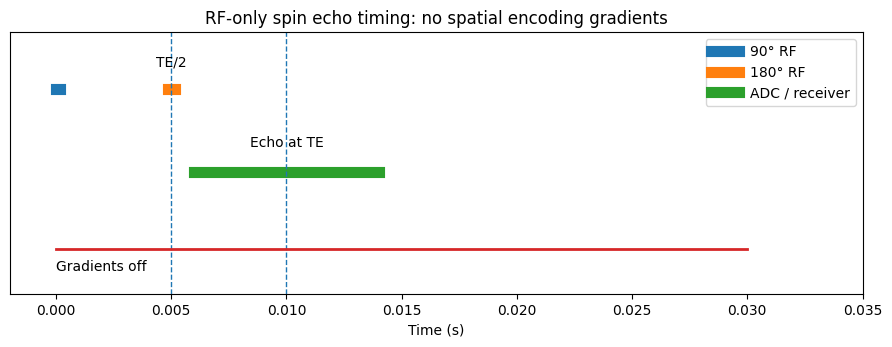

In [8]:
def plot_rf_spin_echo_cartoon(TE, TR, rf90_duration, rf180_duration, adc_duration):
    adc_start = TE - adc_duration / 2
    adc_end = TE + adc_duration / 2
    t180_start = TE/2 - rf180_duration/2
    t180_end = TE/2 + rf180_duration/2

    fig, ax = plt.subplots(figsize=(11, 3.4))

    # RF pulses
    ax.plot([0, rf90_duration], [1.0, 1.0], linewidth=8, label="90° RF")
    ax.plot([t180_start, t180_end], [1.0, 1.0], linewidth=8, label="180° RF")

    # ADC window
    ax.plot([adc_start, adc_end], [0.35, 0.35], linewidth=8, label="ADC / receiver")

    # Echo and TE/2 markers
    ax.axvline(TE/2, linestyle="--", linewidth=1)
    ax.text(TE/2, 1.18, "TE/2", ha="center")
    ax.axvline(TE, linestyle="--", linewidth=1)
    ax.text(TE, 0.55, "Echo at TE", ha="center")

    # Gradient off lanes
    ax.plot([0, min(TR, TE + 0.02)], [-0.25, -0.25], linewidth=2)
    ax.text(0, -0.42, "Gradients off", ha="left")

    ax.set_ylim(-0.6, 1.45)
    ax.set_xlim(-0.002, min(TR, TE + 0.025))
    ax.set_xlabel("Time (s)")
    ax.set_yticks([])
    ax.set_title("RF-only spin echo timing: no spatial encoding gradients")
    ax.legend(loc="upper right")
    plt.show()

plot_rf_spin_echo_cartoon(TE, TR, rf90_duration, rf180_duration, adc_duration)


---
# 5. Build: Create the RF spin echo sequence in PyPulseq

This section constructs the sequence using PyPulseq.

The design intent is:

1. Create a sequence object with scanner limits.
2. Add a 90° RF pulse.
3. Wait until the 180° pulse.
4. Add a 180° RF pulse.
5. Wait until the receiver window.
6. Add an ADC/receiver event centered at TE.
7. Add a TR delay.
8. Plot and export the `.seq` file.

Gradients remain off.


In [9]:
# ----------------------------
# Scanner limits
# ----------------------------
# Placeholder values. Replace with measured/approved DELTA DIY MRI scanner limits.

system = pp.Opts(
    max_grad=10,          # placeholder
    grad_unit="mT/m",
    max_slew=50,          # placeholder
    slew_unit="T/m/s",
    rf_ringdown_time=20e-6,
    rf_dead_time=100e-6,
    adc_dead_time=10e-6,
)

seq = pp.Sequence(system)

print("Sequence object created.")
print("Gradients are disabled for this RF-only spin echo section.")


Sequence object created.
Gradients are disabled for this RF-only spin echo section.


In [10]:
# ----------------------------
# RF pulses
# ----------------------------

rf90 = pp.make_block_pulse(
    flip_angle=np.pi / 2,
    duration=rf90_duration,
    system=system,
)

rf180 = pp.make_block_pulse(
    flip_angle=np.pi,
    duration=rf180_duration,
    system=system,
)

print("RF events created.")
print(f"90° pulse duration  : {rf90_duration*1e6:.1f} µs")
print(f"180° pulse duration : {rf180_duration*1e6:.1f} µs")


RF events created.
90° pulse duration  : 150.0 µs
180° pulse duration : 300.0 µs


In [11]:
# ----------------------------
# ADC / receiver window
# ----------------------------

adc = pp.make_adc(
    num_samples=num_samples,
    duration=adc_duration,
    delay=0,
    system=system,
)

print("ADC event created.")
print(f"ADC samples         : {num_samples}")
print(f"ADC duration        : {adc_duration*1e3:.1f} ms")


ADC event created.
ADC samples         : 1024
ADC duration        : 8.0 ms


In [13]:
# ----------------------------
# Build RF spin echo sequence
# ----------------------------

# 90° pulse starts at t = 0.
seq.add_block(rf90)

# Delay from end of 90° pulse to start of 180° pulse,
# so that the 180° pulse is centered at TE/2.
delay_to_180 = TE/2 - rf90_duration - rf180_duration/2
if delay_to_180 < 0:
    raise ValueError("TE is too short to place the 180° pulse at TE/2.")
seq.add_block(pp.make_delay(delay_to_180))

# 180° pulse
seq.add_block(rf180)

# Delay from end of 180° pulse to start of ADC,
# so that the ADC window is centered at TE.
delay_to_adc = TE/2 - rf180_duration/2 - adc_duration/2
if delay_to_adc < 0:
    raise ValueError("TE is too short to center the ADC window at the echo.")
seq.add_block(pp.make_delay(delay_to_adc))

# Receive around echo
seq.add_block(adc)

# TR delay
used_time = rf90_duration + delay_to_180 + rf180_duration + delay_to_adc + adc_duration
delay_to_TR = TR - used_time
if delay_to_TR < 0:
    raise ValueError(
        f"TR is too short by {-delay_to_TR*1e3:.2f} ms. "
        "Increase TR or shorten RF/ADC durations."
    )
seq.add_block(pp.make_delay(delay_to_TR))

print("RF spin echo sequence constructed.")
print(f"Delay to 180° pulse      : {delay_to_180*1e3:.3f} ms")
print(f"Delay to ADC             : {delay_to_adc*1e3:.3f} ms")
print(f"Used time before TR delay: {used_time*1e3:.3f} ms")
print(f"Final TR delay           : {delay_to_TR*1e3:.3f} ms")


RF spin echo sequence constructed.
Delay to 180° pulse      : 4.700 ms
Delay to ADC             : 0.850 ms
Used time before TR delay: 14.000 ms
Final TR delay           : 986.000 ms


---
# 6. Inspect: Plot the sequence timing

The inspection should answer three questions:

1. Do we see a 90° pulse?
2. Do we see a 180° pulse at TE/2?
3. Is the receiver window centered at TE?


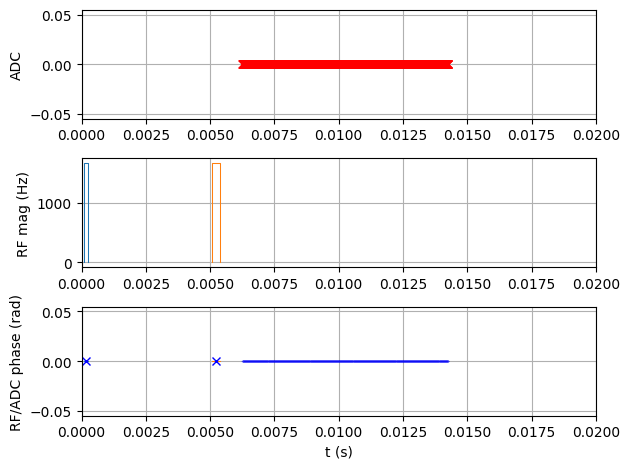

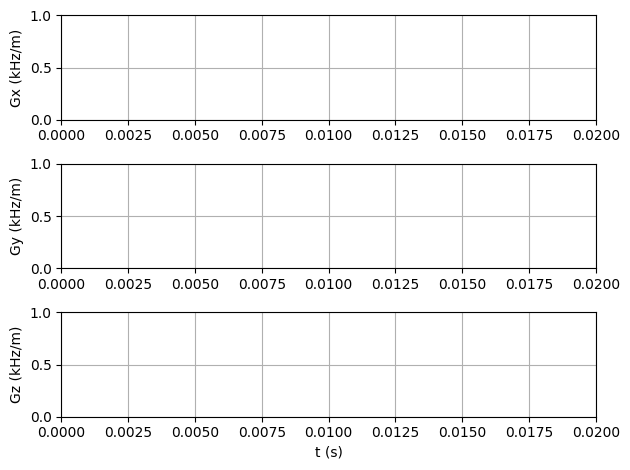

In [16]:
seq.plot(time_range=(0, min(TR, 0.02)))


---
# 7. Validate and export

Before running on the scanner, check timing and export the `.seq` file.


In [17]:
ok, error_report = seq.check_timing()

if ok:
    print("PASS: Sequence timing check passed.")
else:
    print("WARNING: Sequence timing check failed.")
    print(error_report)


['Event: 4 - [type: adc delay: 10.0 us dwell: 7812.5 ns]\n', 'Event: 10 - [type: adc delay: 10.0 us dwell: 7812.5 ns]\n']


In [18]:
out_file = "rf_spin_echo_02516T.seq"
seq.write(out_file)

print(f"Saved sequence file: {out_file}")


Saved sequence file: rf_spin_echo_02516T.seq


/opt/homebrew/lib/python3.10/site-packages/pypulseq/Sequence/write_seq.py:108: FutureWarning: elementwise comparison failed; returning scalar instead, but in the future will perform elementwise comparison
  arb_grad_mask = grad_lib_values == "g"
/opt/homebrew/lib/python3.10/site-packages/pypulseq/Sequence/write_seq.py:109: FutureWarning: elementwise comparison failed; returning scalar instead, but in the future will perform elementwise comparison
  trap_grad_mask = grad_lib_values == "t"


---
# 8. Scan: Day 1 RF SE checklist

Before running this sequence on the scanner:

- [ ] Confirm measured `f0`
- [ ] Confirm RF chain is connected
- [ ] Confirm transmit limits
- [ ] Confirm receive chain and digitizer settings
- [ ] Confirm gradients are disabled
- [ ] Confirm RF pulse-width starting value
- [ ] Confirm expected TE and receiver window
- [ ] Save raw data and console logs
- [ ] Record pulse width, RF amplitude, TE, TR, and observed echo amplitude

Expected Day 1 result:

> A visible RF spin echo near the expected TE.

This sequence will be reused in the RF pulse-width calibration notebook by sweeping `rf90_duration`, `rf180_duration`, or RF amplitude scale and measuring the echo amplitude.


---
# 9. Bridge to the next notebooks

After this RF-only spin echo works, the next steps are:

| Next step | What changes? | Goal |
|---|---|---|
| RF pulse-width calibration | Sweep RF duration or amplitude | Estimate 90°/180° pulse widths |
| 1D spin echo projection | Turn on one readout gradient | Acquire a projection |
| 2D spin echo | Add phase encoding | Acquire a 2D image |

The teaching progression is:

> Start with an echo in time, add one gradient to make a projection, then add phase encoding to make an image.


## Section II — RF Pulse-Width Calibration: How Long Is a 90° Pulse?

In the previous section, we built the first RF spin echo sequence.

Now we will use the same idea to answer a practical scanner question:

> How long should the RF pulse be to produce a 90° excitation?

This matters because the labels **90°** and **180°** do not come from the name of the pulse.  
They come from the amount of rotation that the RF pulse produces in the magnetization.

For a simple rectangular RF pulse, the flip angle is approximately proportional to the RF pulse amplitude and pulse duration:

$$ \alpha = \gamma \int_{0}^{\tau} B_1(t) \, dt $$

If the RF amplitude is constant during the pulse:

$$ \alpha \approx \gamma B_1 \tau $$


where:

- $\alpha$ is the flip angle in radians
- $\gamma$ is the proton gyromagnetic ratio in rad/s/T
- $ B_1^+ $ is the transmit RF field amplitude
- $\tau$ is the RF pulse duration

So, if we keep RF amplitude fixed and increase pulse duration, the magnetization is tipped by a larger angle.

### Learn: Why does pulse width matter?

Think of the RF pulse as a controlled push on the magnetization.

- A short pulse gives a small flip angle.
- A longer pulse gives a larger flip angle.
- A 90° pulse tips magnetization into the transverse plane.
- A 180° pulse inverts or refocuses magnetization.

In practice, we often do not know the exact $ B_1^+ $ field at the sample.  
Therefore, we sweep pulse width experimentally and look for the strongest echo signal.

For a spin echo experiment:

- The first maximum in echo amplitude is usually near the effective 90° excitation condition.
- The next minimum occurs when the excitation pulse has over-rotated toward 180°.
- The pattern continues as the pulse rotates the magnetization through larger angles.

### Design: Choose assumed workshop RF pulse-width values

For this intuition-building simulation, we will assume a range of RF pulse widths near the expected workshop values.

These are dummy values for teaching and planning.  
The real values will be measured on the scanner.

In [19]:
import numpy as np
import matplotlib.pyplot as plt

In [20]:
# ----------------------------
# Dummy RF pulse-width sweep
# ----------------------------

# Candidate pulse widths for the workshop RF pulse-width calibration
# Units: seconds
pw_us = np.linspace(20, 800, 300)       # pulse width in microseconds
pw_s = pw_us * 1e-6

# Choose a dummy "true" 90-degree pulse width for visualization.
# This should be replaced by measured scanner calibration later.
true_pw90_us = 150
true_pw90_s = true_pw90_us * 1e-6

# Flip angle scales linearly with pulse width if RF amplitude is fixed.
# alpha = pi/2 when pulse_width = true_pw90
alpha_rad = (np.pi / 2) * (pw_s / true_pw90_s)
alpha_deg = np.rad2deg(alpha_rad)

print("Dummy pulse-width calibration setup")
print(f"Assumed 90° pulse width : {true_pw90_us:.1f} µs")
print(f"Assumed 180° pulse width: {2*true_pw90_us:.1f} µs")
print(f"Pulse-width sweep range : {pw_us.min():.1f}–{pw_us.max():.1f} µs")

Dummy pulse-width calibration setup
Assumed 90° pulse width : 150.0 µs
Assumed 180° pulse width: 300.0 µs
Pulse-width sweep range : 20.0–800.0 µs


### Build intuition: Pulse width controls flip angle

This plot shows the simplest idea:

> If RF amplitude is fixed, increasing RF pulse width increases the flip angle.

The first important landmarks are:

- 90°: maximum transverse magnetization after excitation
- 180°: magnetization has rotated past the transverse plane
- 270°: transverse magnetization points in the opposite direction
- 360°: magnetization returns toward its starting direction

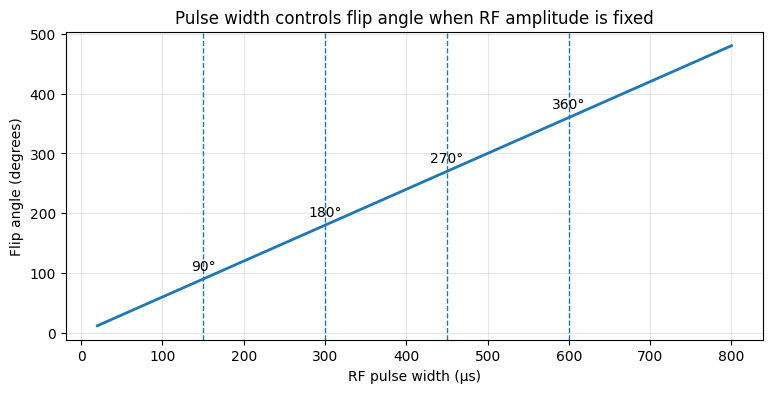

In [21]:
# ----------------------------
# Plot flip angle versus pulse width
# ----------------------------

fig, ax = plt.subplots(figsize=(9, 4))

ax.plot(pw_us, alpha_deg, linewidth=2)

# Mark key flip angles
for angle in [90, 180, 270, 360]:
    pw_at_angle = true_pw90_us * angle / 90
    if pw_us.min() <= pw_at_angle <= pw_us.max():
        ax.axvline(pw_at_angle, linestyle="--", linewidth=1)
        ax.text(
            pw_at_angle,
            angle + 10,
            f"{angle}°",
            ha="center",
            va="bottom"
        )

ax.set_xlabel("RF pulse width (µs)")
ax.set_ylabel("Flip angle (degrees)")
ax.set_title("Pulse width controls flip angle when RF amplitude is fixed")
ax.grid(True, alpha=0.3)
plt.show()

### Build intuition: What signal do we expect?

For a simple excitation experiment, the transverse signal immediately after the RF pulse is proportional to:

$$ M_{xy} \propto \sin(\alpha) $$


This means:

- Signal increases as the pulse approaches 90°.
- Signal is maximum near 90°.
- Signal decreases as the pulse approaches 180°.
- Signal reaches a minimum near 180°.
- The pattern repeats as the pulse width continues to increase.

This is why sweeping RF pulse width helps us identify the effective 90° pulse.

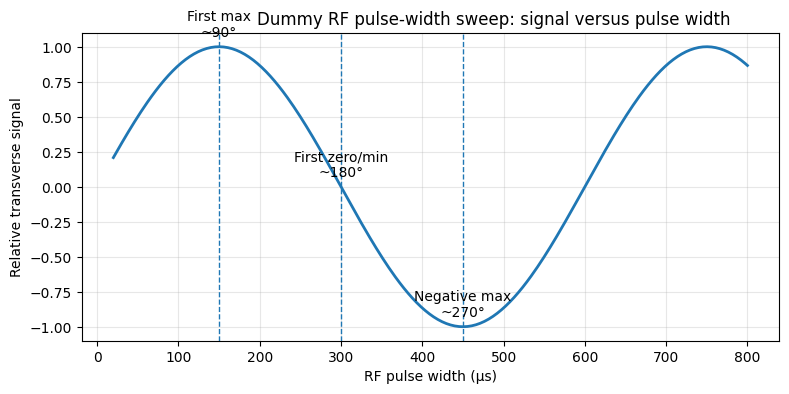

In [22]:
# ----------------------------
# Dummy transverse signal model
# ----------------------------

# Ideal transverse magnetization immediately after excitation
mxy_ideal = np.sin(alpha_rad)

fig, ax = plt.subplots(figsize=(9, 4))

ax.plot(pw_us, mxy_ideal, linewidth=2)

# Mark first maximum and first minimum
pw_90 = true_pw90_us
pw_180 = 2 * true_pw90_us
pw_270 = 3 * true_pw90_us

ax.axvline(pw_90, linestyle="--", linewidth=1)
ax.axvline(pw_180, linestyle="--", linewidth=1)
ax.axvline(pw_270, linestyle="--", linewidth=1)

ax.text(pw_90, 1.05, "First max\n~90°", ha="center", va="bottom")
ax.text(pw_180, 0.05, "First zero/min\n~180°", ha="center", va="bottom")
ax.text(pw_270, -0.95, "Negative max\n~270°", ha="center", va="bottom")

ax.set_xlabel("RF pulse width (µs)")
ax.set_ylabel("Relative transverse signal")
ax.set_title("                        Dummy RF pulse-width sweep: signal versus pulse width")
ax.grid(True, alpha=0.3)
plt.show()

### Spin echo calibration intuition

In the actual RF spin echo experiment, the measured echo amplitude depends on both the excitation pulse and the refocusing pulse.

A simple teaching model is:

$$ S_\mathrm{echo} \propto \sin(\alpha_{90}) \sin^2\left(\frac{\alpha_{180}}{2}\right) $$

For a first workshop calibration, we can keep the relationship simple:

- Set the refocusing pulse width to approximately \(2 \times\) the excitation pulse width.
- Sweep the excitation pulse width.
- Measure the echo amplitude.
- The first strong maximum gives an estimate of the effective 90° pulse width.
- The corresponding 180° pulse width is approximately twice that value.

This will not be a perfect \(B_1^+\) map.  
It is a practical first calibration for producing a usable spin echo.

In [25]:
# ----------------------------
# Dummy spin echo amplitude model
# ----------------------------

# Assume refocusing pulse is always twice the excitation pulse width.
alpha_exc_rad = alpha_rad
alpha_ref_rad = 2 * alpha_exc_rad

# Simple spin echo signal dependence
echo_ideal = np.abs(np.sin(alpha_exc_rad) * (np.sin(alpha_ref_rad / 2) ** 2))

# Add small dummy noise to mimic experimental measurements
rng = np.random.default_rng(7)
noise = 0.04 * rng.normal(size=echo_ideal.shape)
echo_measured_dummy = np.clip(echo_ideal + noise, 0, None)

# Find first local-ish maximum in the teaching range near expected 90
search_mask = (pw_us > 0.5 * true_pw90_us) & (pw_us < 1.5 * true_pw90_us)
idx_search = np.where(search_mask)[0]
idx_max = idx_search[np.argmax(echo_measured_dummy[idx_search])]

estimated_pw90_us = pw_us[idx_max]
estimated_pw180_us = 2 * estimated_pw90_us

print("Dummy calibration result")
print(f"Estimated 90° pulse width : {estimated_pw90_us:.1f} µs")
print(f"Estimated 180° pulse width: {estimated_pw180_us:.1f} µs")

Dummy calibration result
Estimated 90° pulse width : 147.8 µs
Estimated 180° pulse width: 295.7 µs


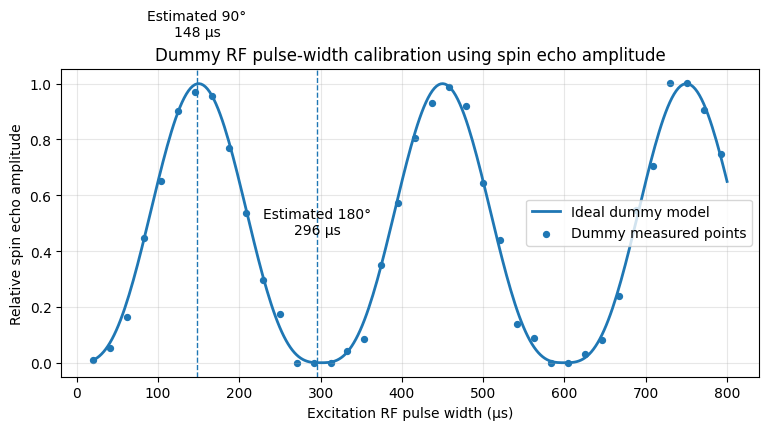

In [26]:
# ----------------------------
# Plot dummy measured spin echo amplitude
# ----------------------------

fig, ax = plt.subplots(figsize=(9, 4))

ax.plot(pw_us, echo_ideal, linewidth=2, label="Ideal dummy model")
ax.scatter(pw_us[::8], echo_measured_dummy[::8], s=18, label="Dummy measured points")

ax.axvline(estimated_pw90_us, linestyle="--", linewidth=1)
ax.text(
    estimated_pw90_us,
    echo_measured_dummy[idx_max] + 0.08,
    f"Estimated 90°\n{estimated_pw90_us:.0f} µs",
    ha="center",
    va="bottom"
)

ax.axvline(estimated_pw180_us, linestyle="--", linewidth=1)
ax.text(
    estimated_pw180_us,
    0.45,
    f"Estimated 180°\n{estimated_pw180_us:.0f} µs",
    ha="center",
    va="bottom"
)

ax.set_xlabel("Excitation RF pulse width (µs)")
ax.set_ylabel("Relative spin echo amplitude")
ax.set_title("Dummy RF pulse-width calibration using spin echo amplitude")
ax.grid(True, alpha=0.3)
ax.legend()
plt.show()

### Design checkpoint

From the dummy sweep, we now have a calibration logic:

1. Start with an RF spin echo sequence.
2. Sweep the excitation pulse width.
3. Set the refocusing pulse width to approximately twice the excitation pulse width.
4. Measure echo amplitude for each pulse width.
5. Identify the first strong maximum.
6. Use that pulse width as the estimated 90° pulse width.
7. Use twice that pulse width as the initial 180° pulse width.

In the real scanner experiment, the measured echo curve may not look as clean as the dummy plot.

Reasons include:

- imperfect RF transmit field
- sample loading
- receive-chain gain variation
- off-resonance
- B0 inhomogeneity
- relaxation during the sequence
- hardware timing delays
- noise and EMI pickup

But the core idea remains the same:

> Pulse width changes flip angle, and flip angle changes the observed echo amplitude.

### Scan / calibrate: What we will record on the scanner

For each pulse-width setting, record:

| Quantity | Example |
|---|---|
| Measured f0 | 10.713 MHz |
| Excitation pulse width | 100–400 µs sweep |
| Refocusing pulse width | 2 × excitation pulse width |
| TE | 10 ms |
| TR | 1000 ms |
| Echo amplitude | measured from raw data |
| Noise estimate | measured before/after echo |
| Notes | visible echo, artifact, clipping, unstable baseline |

The output of this section should be:

- estimated 90° pulse width
- estimated 180° pulse width
- plot of echo amplitude versus pulse width
- selected pulse-width values to use in the 1D and 2D spin echo notebooks

In [14]:
# ----------------------------
# Placeholder table for real scanner measurements
# ----------------------------

calibration_table = {
    "pulse_width_us": [],
    "refocusing_width_us": [],
    "echo_amplitude": [],
    "noise_estimate": [],
    "notes": []
}

print("Calibration table initialized.")
print("During scanner calibration, append one row per pulse-width setting.")

Calibration table initialized.
During scanner calibration, append one row per pulse-width setting.


### Handoff to the next section

The key output from RF pulse-width calibration is:

```python
rf90_duration = estimated_pw90_us * 1e-6
rf180_duration = estimated_pw180_us * 1e-6

Section I: Build the first RF spin echo
Section II: Calibrate pulse width using the RF spin echo
Section III: Use calibrated RF pulses for 1D/2D spatial encoding

# Mini-assignment: Build an RF Pulse-Width Calibration Sequence

## Goal

In the first RF spin echo exercise, we will manually change the RF pulse width and observe how the echo amplitude changes.

Your mini-assignment is to turn that manual process into a simple calibration sequence.

The idea is:

> Build one RF spin echo sequence, then use a `for` loop to repeat it with different RF pulse widths.

This will help us estimate the pulse width that behaves like a **90° excitation pulse** on our low-field scanner.

---

## Background

For a rectangular RF pulse, the flip angle is approximately:

```math
\alpha = \gamma \int_0^\tau B_1^+(t)\,dt
```

If the RF amplitude is constant:

```math
\alpha \approx \gamma B_1^+ \tau
```

So, if we keep RF amplitude fixed and increase the RF pulse width, the magnetization experiences a larger flip angle.

In practice, we do not know the exact $B_1^+$ field at the sample, so we sweep pulse width experimentally and measure the resulting spin echo amplitude.

---

## Assignment

Starting from the RF spin echo sequence, create a pulse-width calibration sequence.

---

### Step 1: Start with a single RF spin echo

Use the RF spin echo sequence with:

- one excitation pulse
- one refocusing pulse
- one ADC/readout window around the expected echo
- no spatial encoding gradients

This is the baseline experiment.

---

### Step 2: Define a pulse-width sweep

Choose a small list of candidate 90° pulse widths.

Example:

```python
pw90_sweep_us = [80, 100, 120, 140, 160, 180, 200, 220, 240, 260, 280, 300]
```

For each candidate excitation pulse width, set:

```python
pw180_us = 2 * pw90_us
```

This is a starting assumption for the refocusing pulse.

---

### Step 3: Wrap the RF spin echo in a loop

Create a `for` loop that adds one RF spin echo block for each pulse-width value.

Conceptually:

```python
for pw90_us in pw90_sweep_us:
    pw180_us = 2 * pw90_us

    # create 90° RF pulse using pw90_us
    # wait until TE/2
    # create 180° RF pulse using pw180_us
    # wait until TE
    # acquire ADC around the echo
    # wait until TR
```

The result should be one sequence file that produces one echo per pulse-width setting.

---

### Step 4: Save metadata

Create a simple table or dictionary that records the pulse-width values used in each repetition.

Example:

```python
calibration_metadata = []

for idx, pw90_us in enumerate(pw90_sweep_us):
    calibration_metadata.append({
        "repetition": idx,
        "pw90_us": pw90_us,
        "pw180_us": 2 * pw90_us,
        "TE_ms": TE * 1e3,
        "TR_ms": TR * 1e3
    })
```

This metadata is important because each acquired echo needs to be matched to the pulse width that produced it.

---

### Step 5: Plot expected calibration behavior

Before running on the scanner, generate a dummy plot showing the expected relationship between pulse width and signal.

A simple model is:

```math
M_{xy} \propto \sin(\alpha)
```

where pulse width controls flip angle.

The first strong maximum should occur near the effective 90° pulse width.

---

## Expected output

Please try to produce:

- [ ] A pulse-width sweep list
- [ ] A `for` loop that repeats the RF spin echo sequence
- [ ] One `.seq` file for the calibration sweep
- [ ] A metadata table linking repetition number to pulse width
- [ ] A dummy plot of expected signal versus pulse width
- [ ] A short note explaining how you would estimate the 90° pulse width from measured echo amplitudes

---

## Stretch goal

After acquiring the data, write a small analysis function that:

1. extracts the echo amplitude from each repetition,
2. plots echo amplitude versus pulse width,
3. identifies the first maximum,
4. reports the estimated 90° and 180° pulse widths.

Example output:

```text
Estimated 90° pulse width: 190 µs
Estimated 180° pulse width: 380 µs
```

---

## Discussion question

What could make the measured echo-amplitude curve differ from the ideal dummy curve?

Possible factors include:

- off-resonance
- imperfect B0 homogeneity
- imperfect B1+ field
- receive gain changes
- relaxation during TE/TR
- noise or EMI pickup
- pulse timing delays
- sample loading

Please post your calibration sequence, plot, or questions in this thread.